In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto
import rasterio
from rasterio.warp import transform as rio_transform
# from scipy.ndimage import uniform_filter   # for spatial smoothing (optional)
import pickle
from tqdm import tqdm

## Loading filtered data

In [ ]:
# --------------------------------------------------------------
# era5_downscaled : (time, 64, 64)   # downscaled GAN output
# chirps          : (time, 64, 64)   # reference CHIRPS
# --------------------------------------------------------------
print("Loading Datasets")
with open('./data/final_chirps.pkl', 'rb') as file:
    final_chirps_dict = pickle.load(file)

with open('./data/final_era5.pkl', 'rb') as file:
    final_era5_dict = pickle.load(file)

dates = np.array(list(final_chirps_dict.keys()))
chirps_dataset = np.array(list(final_chirps_dict.values()))
era5_dataset = np.array(list(final_era5_dict.values()))[:, 2] # Get precipitaion band

Loading Datasets


## Extract extremes

In [ ]:
def annual_maxima(arr):
    """Return (years, 64, 64) array of annual maxima."""
    years = arr.shape[0] // 365
    return np.max(arr.reshape(years, 365, 64, 64), axis=1)

def pot_exceedances(arr, q=0.95):
    """
    Peak over thresholds
    """
    thresh = np.quantile(arr, q, axis=0)
    exceed = arr - thresh
    exceed[exceed < 0] = 0
    mask = exceed > 0
    return exceed, mask, thresh

In [ ]:
exceed_ds, mask_ds, thresh_ds   = pot_exceedances(era5_dataset, q=0.95)
exceed_obs, mask_obs, thresh_obs = pot_exceedances(chirps_dataset, q=0.95)

## Fit GPD per grid cell

In [ ]:
def fit_gpd_grid(exceedances, mask, thresh_grid, min_exceedances=30):
    """
    Fitting Generalized Pareto Distribution (GPD)
    """
    shape = np.full((64, 64), np.nan)
    scale = np.full((64, 64), np.nan)
    n_exc = mask.sum(axis=0)
    valid = n_exc >= min_exceedances

    for i in tqdm(range(64)):
        for j in range(64):
            if not valid[i, j]:
                continue
            data = exceedances[mask[:, i, j], i, j]
            if len(data) == 0:
                continue
            try:
                c, _, sigma = genpareto.fit(data, floc=0)
                shape[i, j] = c
                scale[i, j] = sigma
            except:
                pass
    return shape, scale, thresh_grid, valid

In [33]:
shape_ds, scale_ds, thresh_ds_grid, valid_ds = fit_gpd_grid(
        exceed_ds, mask_ds, thresh_ds)
shape_obs, scale_obs, thresh_obs_grid, valid_obs = fit_gpd_grid(
        exceed_obs, mask_obs, thresh_obs)

100%|██████████| 64/64 [00:23<00:00,  2.76it/s]


## Build the “Pareto plot” (return-period curve) for a single cell

In [ ]:
def return_level(shape, scale, thresh, rp, rate=1.0):
    """
    Return-level function (GPD)
    rp   : return period in years
    rate : average exceedances per year (≈ (1-q)*365)
    """
    if shape == 0:
        return thresh + scale * np.log(rp * rate)
    else:
        return thresh + scale/shape * ((rp*rate)**shape - 1)

def plot_pareto_cell(i, j, location_name, rp_vec=np.logspace(0.3,2,100)):
    if not (valid_ds[i,j] and valid_obs[i,j]):
        print(f"Cell ({i},{j}) has too few extremes")
        return
    rl_ds  = return_level(shape_ds[i,j], scale_ds[i,j],
                          thresh_ds_grid[i,j], rp_vec, rate=0.05*365)
    rl_obs = return_level(shape_obs[i,j], scale_obs[i,j],
                          thresh_obs_grid[i,j], rp_vec, rate=0.05*365)

    plt.figure(figsize=(6,4), dpi=200)
    plt.plot(rp_vec, rl_obs, label='CHIRPS', lw=2)
    plt.plot(rp_vec, rl_ds,  label='ERA5', lw=2, ls='--')
    plt.xscale('log')
    plt.xlabel('Return period (years)')
    plt.ylabel('Return level (mm day⁻¹)')
    plt.title(f'GPD return-level curve - {location_name}')
    plt.legend()
    plt.grid(True, which='both', ls=':')
    plt.tight_layout()
    plt.show()

In [85]:
chirps_tif = "../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2020-06-01.tif"    # (time, lat, lon)  – 0.05°

# List of extreme-rainfall locations you already have
#   format: [(lon1, lat1), (lon2, lat2), ...]
extreme_locs = {
    "Dehradun": (78.04699494260008, 30.31438921393443),
    "Uttar Kashi": (78.44195745611083, 30.727701300923005),
    "Nainital": (79.45378873558052, 29.38500689445674),
    "Pithoragarh": (80.21142992737175, 29.581815794485664)
}

def latlon_to_idx(dataset, lat, lon):
    """
    Return (row, col) integer indices for a point (lat, lon).
    Works for any GeoTIFF that rasterio can open.
    """
    # rasterio uses (col, row) order for ~ operator
    col, row = ~dataset.transform * (lon, lat)
    row, col = int(round(row)), int(round(col))
    # Clip to valid range
    row = np.clip(row, 0, dataset.height - 1)
    col = np.clip(col, 0, dataset.width  - 1)
    return row, col

with rasterio.open(chirps_tif) as ds_chirps:
    # ---- sanity check: both rasters must have the same number of bands (days)
    # assert ds_era5.count == ds_chirps.count, "ERA5 and CHIRPS must have same # of days"

    # ---- convert every (lat,lon) → (row,col) for BOTH rasters
    cell_list = {}
    for location, (lon, lat) in extreme_locs.items():
        r_c, c_c = latlon_to_idx(ds_chirps, lat, lon)   # CHIRPS (reference)
        # cell_list.append({
        #     "lat": lat, "lon": lon,
        #     "chirps_idx": (r_c, c_c)
        # })
        cell_list[location] = (r_c, c_c)
# plot_pareto_cell(63, 63)   # change indices as you wish

In [86]:
cell_list

{'Dehradun': (np.int64(33), np.int64(5)),
 'Uttar Kashi': (np.int64(24), np.int64(13)),
 'Nainital': (np.int64(51), np.int64(33)),
 'Pithoragarh': (np.int64(47), np.int64(48))}

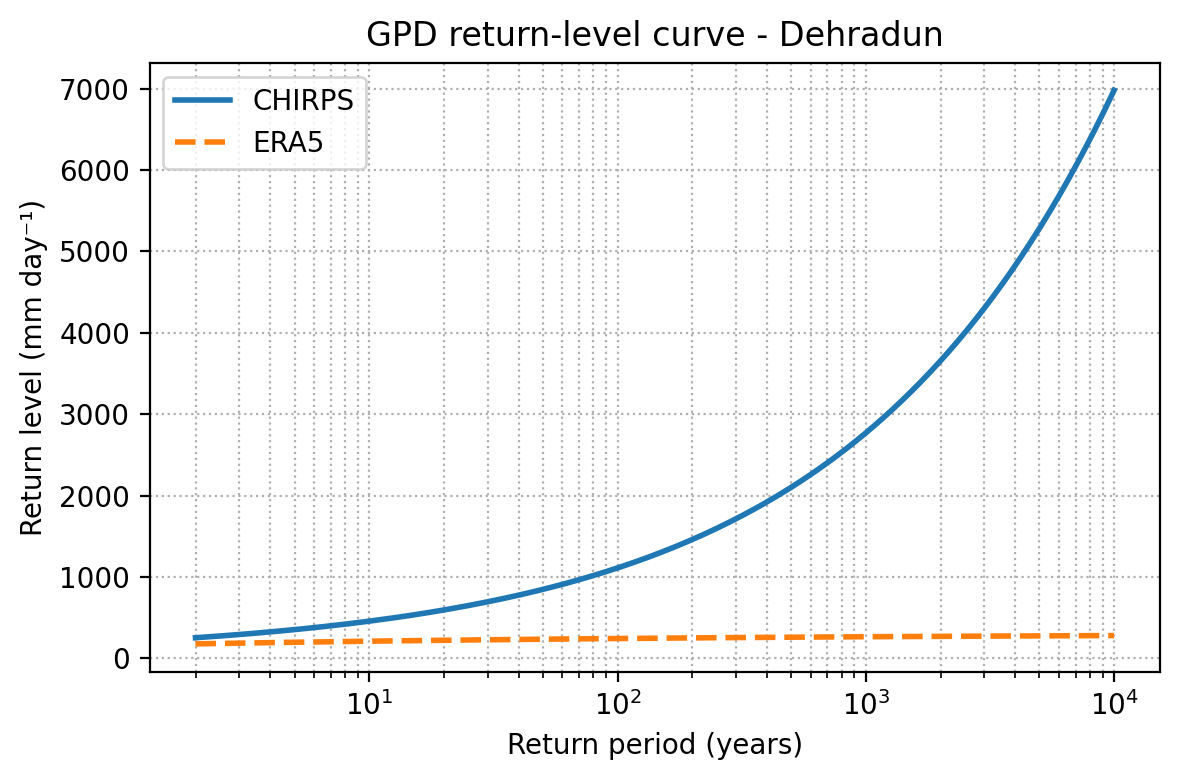

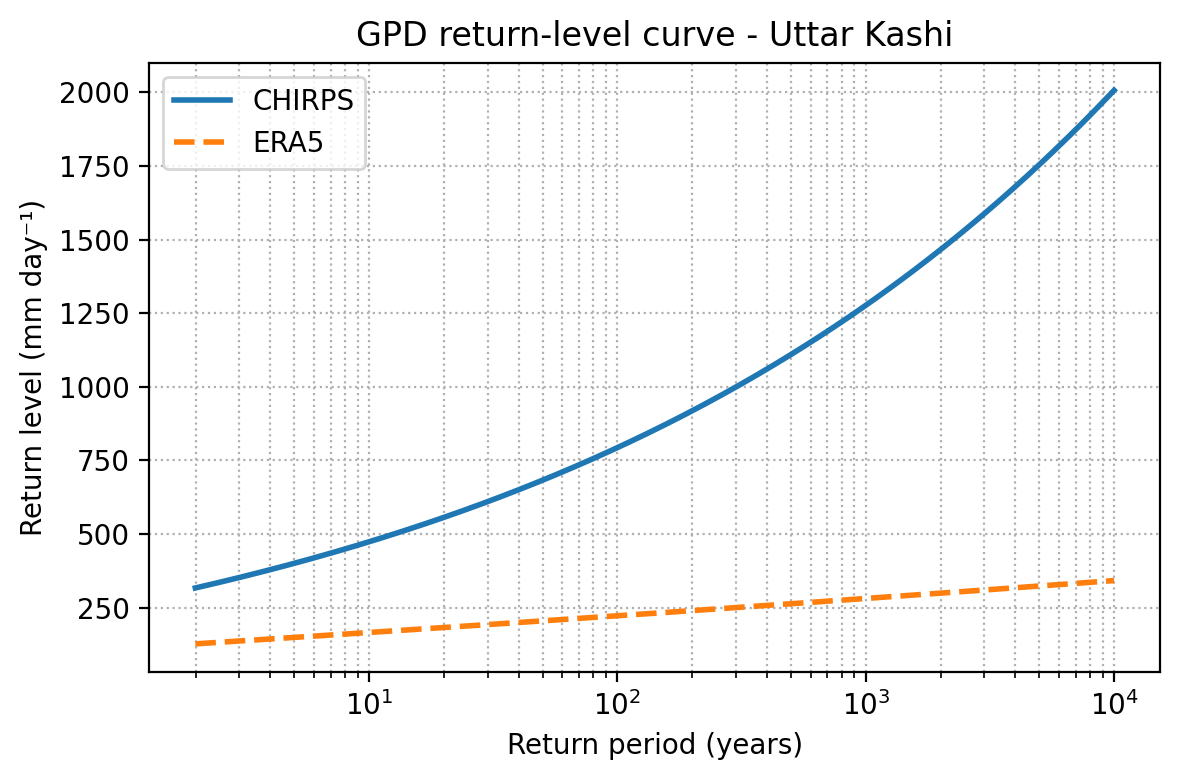

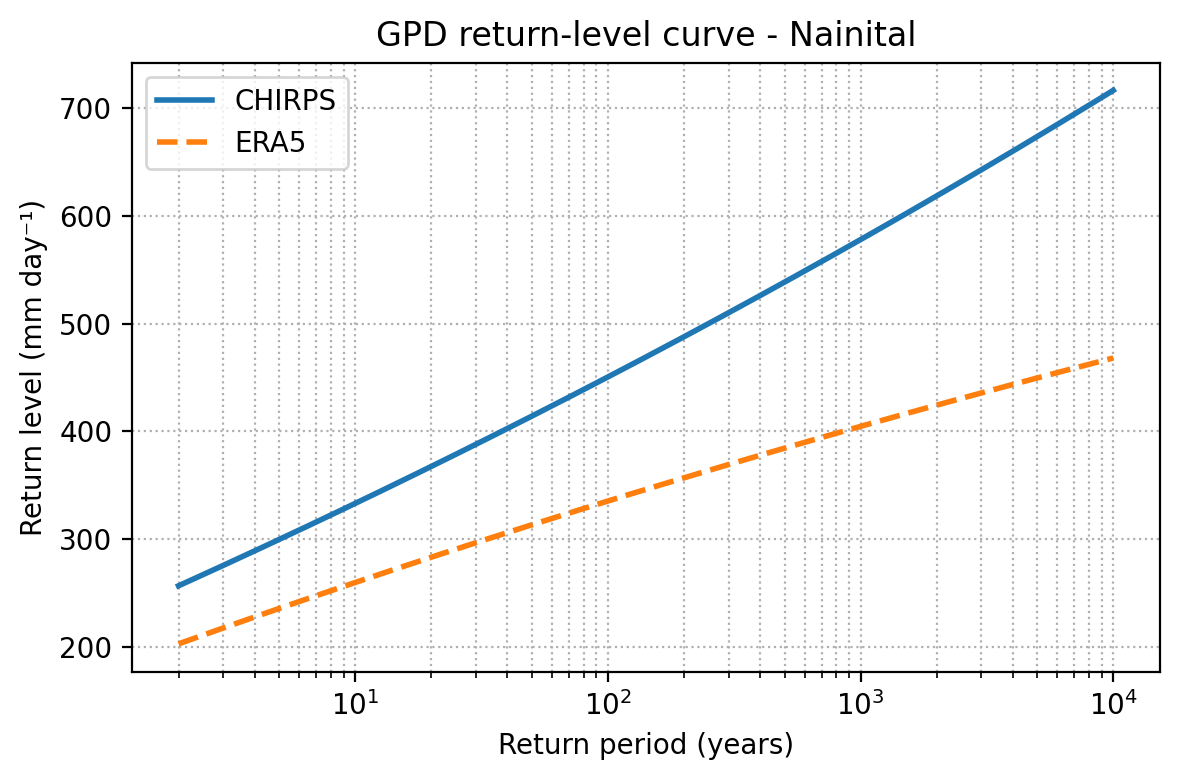

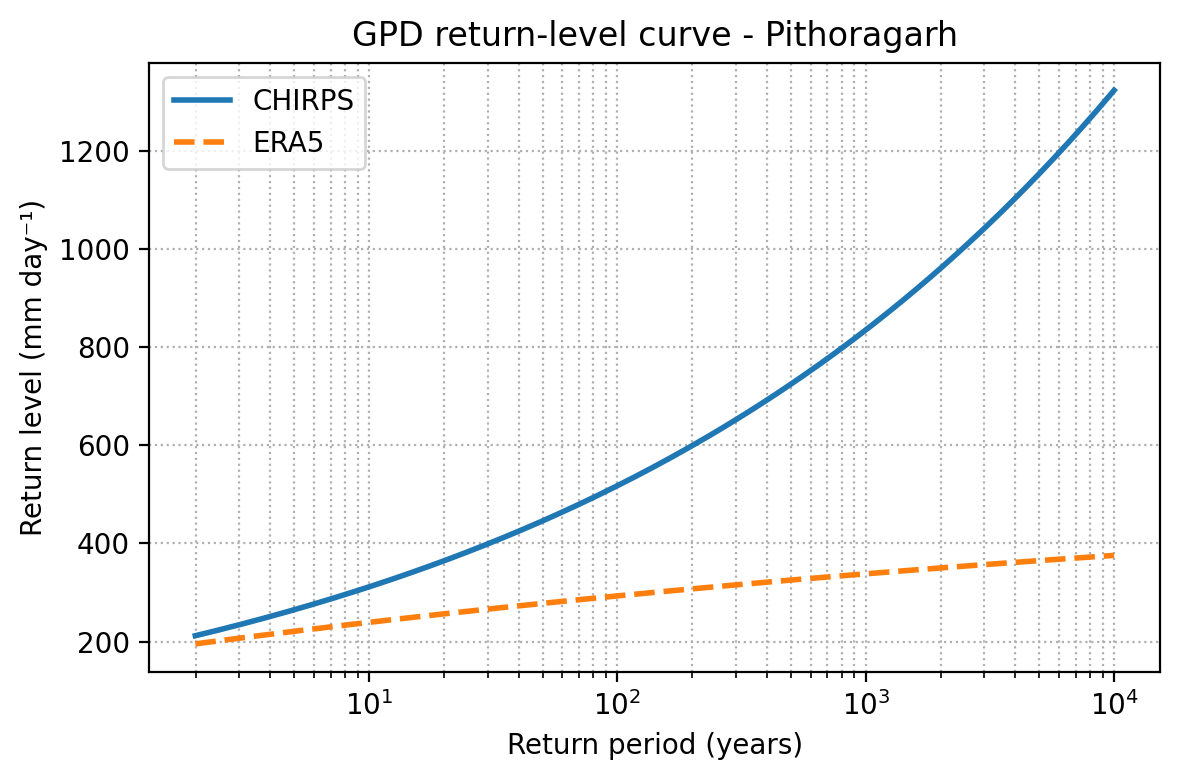

In [91]:
return_levels = np.logspace(0.3, 4, 200)
plot_pareto_cell(*cell_list["Dehradun"], location_name="Dehradun", rp_vec=return_levels)
plot_pareto_cell(*cell_list["Uttar Kashi"], location_name="Uttar Kashi", rp_vec=return_levels)
plot_pareto_cell(*cell_list["Nainital"], location_name="Nainital", rp_vec=return_levels)
plot_pareto_cell(*cell_list["Pithoragarh"], location_name="Pithoragarh", rp_vec=return_levels)

## 7. Bias map of a chosen return level (e.g. 100-yr)

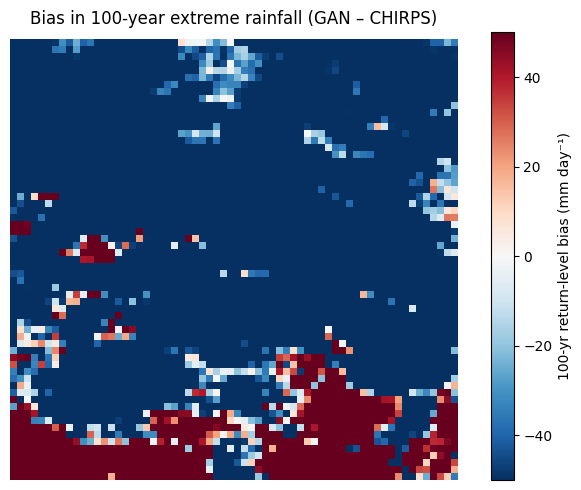

In [ ]:
rp100 = 100.0
rl100_ds  = np.full((64,64), np.nan)
rl100_obs = np.full((64,64), np.nan)

rate = 0.05*365                     # 5 % of days exceed threshold → ~18 per year
for i in range(64):
    for j in range(64):
        if valid_ds[i,j]:
            rl100_ds[i,j] = return_level(shape_ds[i,j], scale_ds[i,j],
                                         thresh_ds_grid[i,j], rp100, rate)
        if valid_obs[i,j]:
            rl100_obs[i,j] = return_level(shape_obs[i,j], scale_obs[i,j],
                                          thresh_obs_grid[i,j], rp100, rate)

bias100 = rl100_ds - rl100_obs

plt.figure(figsize=(7,5))
im = plt.imshow(bias100, cmap='RdBu_r', vmin=-50, vmax=50)
plt.colorbar(im, label='100-yr return-level bias (mm day⁻¹)')
plt.title('Bias in 100-year extreme rainfall (GAN – CHIRPS)')
plt.axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_23551/3281726861.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/workspace/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


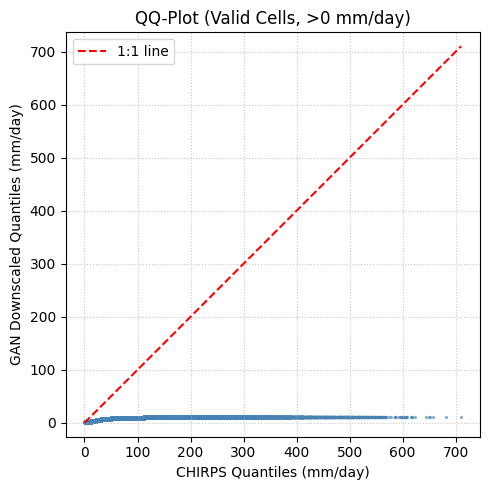

In [ ]:
valid = valid_ds & valid_obs  # (64, 64) boolean

# Extract data from valid cells only
data_ds  = era5_dataset[:, valid].ravel()
data_obs = chirps_dataset[:, valid].ravel()

# Remove zeros and sort
data_ds  = np.sort(data_ds[data_ds > 0])
data_obs = np.sort(data_obs[data_obs > 0])

# Take the shorter length to align
min_len = min(len(data_ds), len(data_obs))
qq_ds  = data_ds[:min_len]
qq_obs = data_obs[:min_len]

# Now scatter is safe
plt.figure(figsize=(5, 5))
plt.scatter(qq_obs, qq_ds, s=2, alpha=0.5, color='steelblue')
lims = [0, max(qq_obs.max(), qq_ds.max())]
plt.plot(lims, lims, 'r--', label='1:1 line')
plt.xlabel('CHIRPS Quantiles (mm/day)')
plt.ylabel('GAN Downscaled Quantiles (mm/day)')
plt.title('QQ-Plot (Valid Cells, >0 mm/day)')
plt.legend()
plt.grid(True, ls=':', alpha=0.7)
plt.axis('equal')
plt.tight_layout()
plt.show()

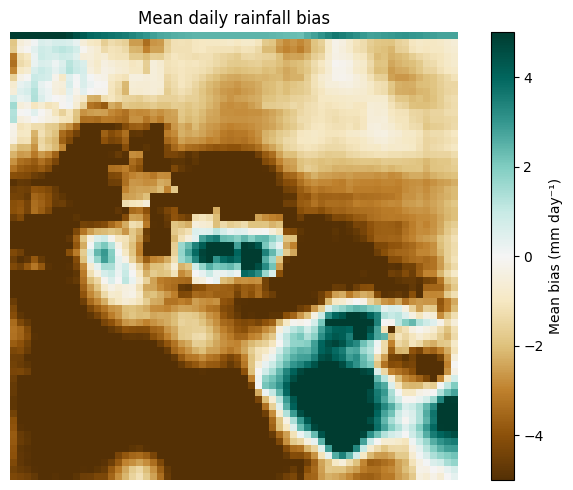

In [41]:
# 8.2 Mean bias map (daily values)
mean_ds  = era5_dataset.mean(axis=0)
mean_obs = chirps_dataset.mean(axis=0)
bias_map = mean_ds - mean_obs

plt.figure(figsize=(7,5))
plt.imshow(bias_map, cmap='BrBG', vmin=-5, vmax=5)
plt.colorbar(label='Mean bias (mm day⁻¹)')
plt.title('Mean daily rainfall bias')
plt.axis('off')
plt.tight_layout()
plt.show()

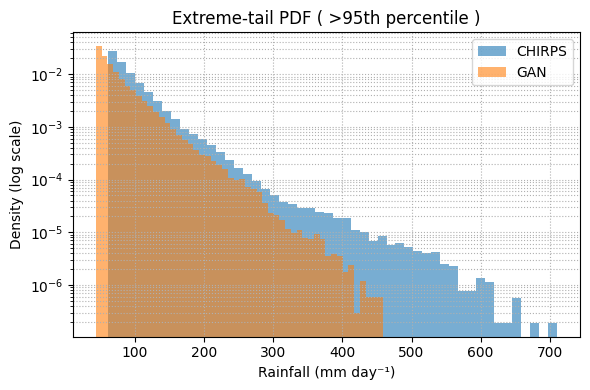

In [42]:
# 8.3 PDF overlay (log-scale, extremes only)
ext_ds  = era5_dataset[era5_dataset > np.percentile(era5_dataset, 95)]
ext_obs = chirps_dataset[chirps_dataset > np.percentile(chirps_dataset, 95)]

plt.figure(figsize=(6,4))
plt.hist(ext_obs, bins=50, density=True, alpha=0.6, label='CHIRPS', color='C0')
plt.hist(ext_ds , bins=50, density=True, alpha=0.6, label='GAN'   , color='C1')
plt.yscale('log')
plt.xlabel('Rainfall (mm day⁻¹)')
plt.ylabel('Density (log scale)')
plt.title('Extreme-tail PDF ( >95th percentile )')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()